# BraTS2020 Beyin Tümörü Segmentasyonu: U-Net vs SAM vs MedSAM
**Yazar:** Zeynep Bölükbaşı — 25832901037

## Çalışma Özeti
Bu notebook, BraTS2020 H5 slice veri seti üzerinde üç farklı segmentasyon modelini
karşılaştırır:

| Model | Tür | Eğitim |
|---|---|---|
| **U-Net** | Task-specific (görev odaklı) | BraTS2020 üzerinde supervised eğitim |
| **SAM** | Foundation model (genel amaçlı) | Zero-shot — eğitim yok |
| **MedSAM** | Foundation model (medikal domain) | Zero-shot — validation-only prompt optimizasyonu |

**Segmentasyon hedefi:** Binary Whole Tumor (WT) maskesi  
**Metrikler:** Dice Coefficient, IoU  
**Split stratejisi:** Volume-level (hasta sızıntısını önlemek için)

> **Not:** Tüm MedSAM parametresi araması yalnızca **validation set** üzerinde yapılır.
> Test seti sadece final raporlama için bir kez kullanılır.


## 0. Kurulum ve Kütüphane Yükleme

In [2]:
# Google Drive bağlantısı (Colab için)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Gerekli kütüphanelerin kurulumu
!pip install -q kagglehub h5py nibabel SimpleITK monai torchmetrics \
    opencv-python scikit-learn tqdm matplotlib pandas scipy ipywidgets
!pip install -q git+https://github.com/facebookresearch/segment-anything.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 136.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
# ── Temel importlar ──────────────────────────────────────────────────────
import os
import re
import gc
import glob
import time
import random
import warnings

import h5py
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy import ndimage
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ── Cihaz seçimi ─────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch    :", torch.__version__)
print("CUDA     :", torch.cuda.is_available())
print("Device   :", DEVICE)

# ── Global hiperparametreler ─────────────────────────────────────────────
IMAGE_SIZE_UNET          = 256    # U-Net için input boyutu
IMAGE_SIZE_SAM_BASELINE  = 256    # SAM baseline için input boyutu
IMAGE_SIZE_MEDSAM        = 1024   # MedSAM için input boyutu (daha iyi performans)
BATCH_SIZE               = 32
EPOCHS                   = 20
NEGATIVE_RATIO           = 0.20   # Eğitim setinde negatif slice oranı

# MedSAM validation tuning için örnek sayısı:
# Hızlı çalıştırma için 300, daha sağlam sonuç için 1000+
VAL_TUNE_SAMPLES         = 1000

OUTPUT_DIR = "/content/brats2020_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory:", OUTPUT_DIR)

# ── Süre takibi ──────────────────────────────────────────────────────────
timing_records = []

def format_seconds(s):
    s = float(s)
    if s < 60:   return f"{s:.2f} sec"
    if s < 3600: return f"{s/60:.2f} min"
    return f"{s/3600:.2f} hr"


Torch    : 2.11.0+cu128
CUDA     : True
Device   : cuda
Output directory: /content/brats2020_outputs


## 1. BraTS2020 Veri Seti

KaggleHub üzerinden BraTS2020 H5 slice veri seti indirilir.
Her `.h5` dosyasında:
- `image`: shape `(240, 240, 4)` — 4 MRI modalitesi (FLAIR, T1, T1ce, T2)
- `mask`: shape `(240, 240, 3)` — tümör maskesi kanalları

Mask **binary Whole Tumor (WT)** formatına çevrilir:
herhangi bir mask kanalı pozitifse → tümör var.


In [5]:
# ── Veri seti indirme ────────────────────────────────────────────────────
import kagglehub

dataset_path = kagglehub.dataset_download("awsaf49/brats2020-training-data")
print("Dataset path:", dataset_path)

h5_files = sorted(glob.glob(os.path.join(dataset_path, "**", "*.h5"), recursive=True))
print("Toplam H5 dosya sayısı:", len(h5_files))
print("Örnek dosyalar:", h5_files[:3])


100%|██████████| 6.76G/6.76G [00:49<00:00, 148MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3
Toplam H5 dosya sayısı: 57195
Örnek dosyalar: ['/root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3/BraTS2020_training_data/content/data/volume_100_slice_0.h5', '/root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3/BraTS2020_training_data/content/data/volume_100_slice_1.h5', '/root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3/BraTS2020_training_data/content/data/volume_100_slice_10.h5']


Örnek dosya : /root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3/BraTS2020_training_data/content/data/volume_100_slice_100.h5
Image shape : (240, 240, 4) float64
Mask shape  : (240, 240, 3) uint8


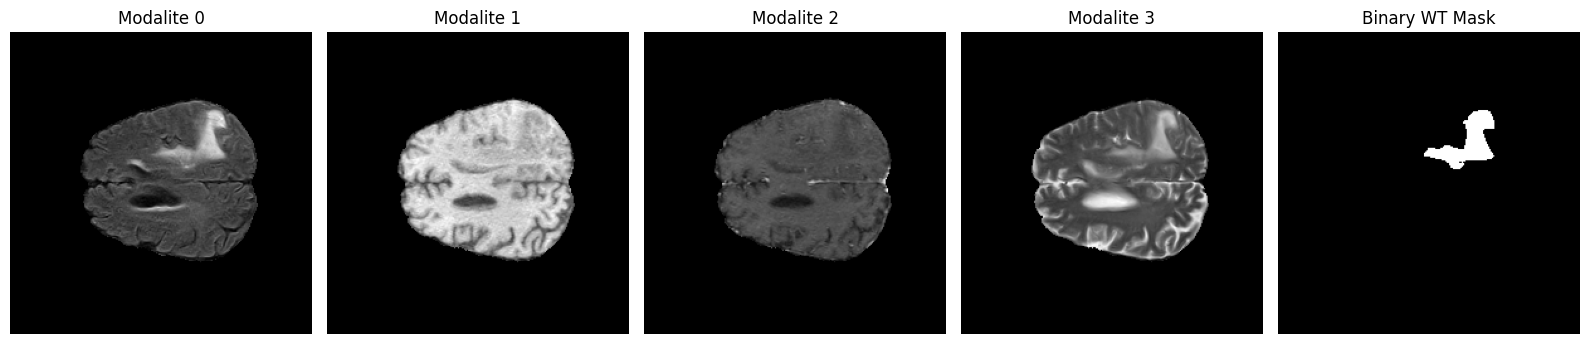

In [6]:
# ── Tek örnek inceleme ───────────────────────────────────────────────────
def read_h5(path):
    """H5 dosyasından image ve mask okur."""
    with h5py.File(path, "r") as f:
        image = f["image"][:]
        mask  = f["mask"][:]
    return image, mask

def mask_to_binary(mask):
    """Çok kanallı maskeyi binary Whole Tumor maskesine çevirir."""
    if mask.ndim == 3:
        return (np.sum(mask, axis=-1) > 0).astype(np.uint8)
    return (mask > 0).astype(np.uint8)

def has_tumor(path):
    _, mask = read_h5(path)
    return np.sum(mask > 0) > 0

def is_valid_slice(path):
    """Tamamen boş (siyah) image slice'ları filtreler."""
    image, _ = read_h5(path)
    return np.max(image) > 0

# İlk geçerli tümör slice'ını bul ve görüntüle
sample_h5 = next((p for p in h5_files if is_valid_slice(p) and has_tumor(p)), None)
image, mask = read_h5(sample_h5)
binary_mask = mask_to_binary(mask)

print("Örnek dosya :", sample_h5)
print("Image shape :", image.shape, image.dtype)
print("Mask shape  :", mask.shape, mask.dtype)

plt.figure(figsize=(16, 4))
for i in range(4):
    plt.subplot(1, 5, i+1)
    plt.imshow(image[:, :, i], cmap="gray")
    plt.title(f"Modalite {i}")
    plt.axis("off")
plt.subplot(1, 5, 5)
plt.imshow(binary_mask, cmap="gray")
plt.title("Binary WT Mask")
plt.axis("off")
plt.tight_layout()
plt.show()


## 2. Volume-Level Train / Validation / Test Bölünmesi

Slice-level split yerine **volume-level split** kullanılır.
Bu sayede aynı hastaya ait slice'lar hem train hem test setine düşmez
(hasta sızıntısı önlenir).

Split oranları: **%70 train — %15 validation — %15 test**


In [7]:
# ── Volume ID çıkarma ────────────────────────────────────────────────────
def extract_volume_id(path):
    """
    Dosya adından volume ID'sini çıkarır.
    Örnek: volume_118_slice_50.h5 → '118'
    """
    name = os.path.basename(path)
    match = re.search(r"volume_(\d+)_slice_", name)
    if match is None:
        raise ValueError(f"Volume ID çıkarılamadı: {name}")
    return match.group(1)

# Boş slice'ları filtrele
valid_h5_files = [
    p for p in tqdm(h5_files, desc="Geçerli slice'lar filtreleniyor")
    if is_valid_slice(p)
]
print("Geçerli (boş olmayan) H5 dosyası:", len(valid_h5_files))

# Volume-level split
volume_ids    = [extract_volume_id(p) for p in valid_h5_files]
unique_volumes = sorted(set(volume_ids))

train_volumes, temp_volumes = train_test_split(unique_volumes, test_size=0.30, random_state=SEED)
val_volumes,   test_volumes = train_test_split(temp_volumes,   test_size=0.50, random_state=SEED)

train_volumes = set(train_volumes)
val_volumes   = set(val_volumes)
test_volumes  = set(test_volumes)

train_files = [p for p in valid_h5_files if extract_volume_id(p) in train_volumes]
val_files   = [p for p in valid_h5_files if extract_volume_id(p) in val_volumes]
test_files  = [p for p in valid_h5_files if extract_volume_id(p) in test_volumes]

print(f"Benzersiz volume sayısı : {len(unique_volumes)}")
print(f"Train / Val / Test volume: {len(train_volumes)} / {len(val_volumes)} / {len(test_volumes)}")
print(f"Train / Val / Test slice : {len(train_files)} / {len(val_files)} / {len(test_files)}")


Geçerli slice'lar filtreleniyor: 100%|██████████| 57195/57195 [07:12<00:00, 132.32it/s]


Geçerli (boş olmayan) H5 dosyası: 50899
Benzersiz volume sayısı : 369
Train / Val / Test volume: 258 / 55 / 56
Train / Val / Test slice : 35573 / 7599 / 7727


In [8]:
# ── Slice seçimi: tümör pozitif + az negatif ──────────────────────────────
# U-Net eğitiminde sınıf dengesizliğini azaltmak için:
# - Tümör pozitif slice'ların tamamı alınır.
# - Tümör negatif slice'lardan rastgele %20 oranında eklenir.
# SAM/MedSAM karşılaştırması için yalnızca tümör pozitif slice'lar kullanılır.

def select_tumor_and_negative_slices(files, negative_ratio=0.20, seed=42):
    rng = random.Random(seed)
    tumor_files    = [p for p in files if has_tumor(p)]
    negative_files = [p for p in files if not has_tumor(p)]
    n_negative     = min(int(len(tumor_files) * negative_ratio), len(negative_files))
    selected_neg   = rng.sample(negative_files, n_negative)
    selected       = tumor_files + selected_neg
    rng.shuffle(selected)
    return selected

train_files_selected = select_tumor_and_negative_slices(train_files, NEGATIVE_RATIO, SEED)
val_files_selected   = select_tumor_and_negative_slices(val_files,   NEGATIVE_RATIO, SEED)
test_files_selected  = select_tumor_and_negative_slices(test_files,  NEGATIVE_RATIO, SEED)

# SAM/MedSAM için: yalnızca tümör içeren slice'lar
val_files_tumor_only  = [p for p in val_files_selected  if has_tumor(p)]
test_files_tumor_only = [p for p in test_files_selected if has_tumor(p)]

split_summary = pd.DataFrame([
    ["train",      len(train_files_selected), sum(has_tumor(p) for p in train_files_selected)],
    ["validation", len(val_files_selected),   sum(has_tumor(p) for p in val_files_selected)],
    ["test",       len(test_files_selected),  sum(has_tumor(p) for p in test_files_selected)],
    ["val  (tumor-only)",  len(val_files_tumor_only),  len(val_files_tumor_only)],
    ["test (tumor-only)", len(test_files_tumor_only), len(test_files_tumor_only)],
], columns=["Split", "Toplam slice", "Tümör pozitif slice"])

print(split_summary.to_string(index=False))


            Split  Toplam slice  Tümör pozitif slice
            train         20191                16826
       validation          4458                 3715
             test          4657                 3881
val  (tumor-only)          3715                 3715
test (tumor-only)          3881                 3881


## 3. Ortak Yardımcı Fonksiyonlar

Tüm modeller için kullanılan:
- **Normalizasyon**: min-max (U-Net/SAM) ve percentile-clipping (MedSAM)
- **Metrikler**: Dice, IoU (NumPy ve PyTorch versiyonları)
- **Bounding box üretimi**: Ground-truth maskeden SAM/MedSAM prompt oluşturur
- **Postprocessing**: Largest connected component seçimi


In [9]:
# ── Normalizasyon ────────────────────────────────────────────────────────
def normalize_minmax(image):
    """Kanal bazlı min-max normalizasyon (U-Net ve SAM için)."""
    image     = image.astype(np.float32)
    image_min = image.min(axis=(0, 1), keepdims=True)
    image_max = image.max(axis=(0, 1), keepdims=True)
    return (image - image_min) / (image_max - image_min + 1e-8)

def normalize_percentile(x):
    """
    Percentile clipping + min-max normalizasyon (MedSAM için).
    MedSAM medikal görüntüler için bu preprocessing ile eğitildiğinden
    bu normalizasyon U-Net/SAM'e kıyasla daha iyi sonuç verir.
    """
    x      = x.astype(np.float32)
    nonzero = x[x != 0]
    if len(nonzero) > 0:
        p_low, p_high = np.percentile(nonzero, (0.5, 99.5))
        x = np.clip(x, p_low, p_high)
    x_min, x_max = x.min(), x.max()
    if x_max - x_min > 1e-8:
        x = (x - x_min) / (x_max - x_min)
    else:
        x = np.zeros_like(x)
    return x

# ── Preprocessing: U-Net / SAM ────────────────────────────────────────────
def prepare_h5_rgb(path, image_size=256, use_channels=(0, 1, 3)):
    """
    H5 slice'ı U-Net veya SAM için hazırlar.
    Çıktı: (uint8 RGB image, binary mask)
    """
    image, mask = read_h5(path)
    gt_mask = mask_to_binary(mask)
    image   = image[:, :, list(use_channels)]
    image   = normalize_minmax(image)
    image   = cv2.resize(image,   (image_size, image_size), interpolation=cv2.INTER_LINEAR)
    gt_mask = cv2.resize(gt_mask, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
    return (image * 255).clip(0, 255).astype(np.uint8), gt_mask.astype(np.uint8)

# ── Preprocessing: MedSAM ─────────────────────────────────────────────────
def prepare_h5_for_medsam(path, image_size=1024, use_channels=(0, 1, 2)):
    """
    H5 slice'ı MedSAM için hazırlar.
    - Percentile clipping normalizasyon kullanır.
    - Default 1024x1024 input boyutu (MedSAM bu boyutta eğitildi).
    - Default channels: (0,1,2) — deneylerle belirlendi.
    """
    image, mask = read_h5(path)
    gt_mask     = mask_to_binary(mask)
    image       = image[:, :, list(use_channels)]
    norm_channels = [normalize_percentile(image[:, :, c]) for c in range(image.shape[-1])]
    image = np.stack(norm_channels, axis=-1)
    image   = cv2.resize(image,   (image_size, image_size), interpolation=cv2.INTER_CUBIC)
    gt_mask = cv2.resize(gt_mask, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
    return (image * 255).clip(0, 255).astype(np.uint8), gt_mask.astype(np.uint8)

# ── Metrikler (NumPy) ─────────────────────────────────────────────────────
def dice_np(pred, target, eps=1e-7):
    pred, target = pred.astype(bool), target.astype(bool)
    inter = np.logical_and(pred, target).sum()
    union = pred.sum() + target.sum()
    return float((2.0 * inter + eps) / (union + eps))

def iou_np(pred, target, eps=1e-7):
    pred, target = pred.astype(bool), target.astype(bool)
    inter = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()
    return float((inter + eps) / (union + eps))

# ── Metrikler (PyTorch — U-Net eğitimi için) ──────────────────────────────
def dice_torch(pred, target, eps=1e-7):
    pred, target = pred.float(), target.float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2 * inter + eps) / (union + eps)).mean()

def iou_torch(pred, target, eps=1e-7):
    pred, target = pred.float(), target.float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - inter
    return ((inter + eps) / (union + eps)).mean()

# ── Bounding Box (SAM/MedSAM prompt) ─────────────────────────────────────
def get_bbox_from_mask(mask, padding=5):
    """
    Ground-truth maskeden bounding box prompt üretir.
    Bu 'oracle prompt' yaklaşımıdır — kontrollü karşılaştırma için.
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    h, w = mask.shape
    return np.array([
        max(0,   xs.min() - padding),
        max(0,   ys.min() - padding),
        min(w-1, xs.max() + padding),
        min(h-1, ys.max() + padding),
    ])

# ── Postprocessing ────────────────────────────────────────────────────────
def keep_largest_component(mask):
    """Küçük gürültü bölgelerini temizler; yalnızca en büyük bağlı bileşeni tutar."""
    mask_bool        = mask.astype(bool)
    labeled, num     = ndimage.label(mask_bool)
    if num == 0:
        return mask.astype(np.uint8)
    sizes            = ndimage.sum(mask_bool, labeled, range(1, num + 1))
    largest_label    = int(np.argmax(sizes) + 1)
    return (labeled == largest_label).astype(np.uint8)

# ── Nokta örnekleme (SAM/MedSAM için isteğe bağlı prompt) ────────────────
def sample_points(mask, bbox=None, num_pos=0, num_neg=0, seed=42):
    """Maskeden pozitif/negatif nokta promptları örnekler."""
    rng    = np.random.default_rng(seed)
    points, labels = [], []
    if num_pos > 0:
        ys, xs = np.where(mask > 0)
        if len(xs) > 0:
            idx = rng.choice(len(xs), size=min(num_pos, len(xs)), replace=False)
            points.append(np.stack([xs[idx], ys[idx]], axis=1))
            labels.append(np.ones(len(idx), dtype=np.int32))
    if num_neg > 0:
        h, w = mask.shape
        if bbox is not None:
            x0, y0, x1, y1 = bbox.astype(int)
            region = np.zeros_like(mask, dtype=np.uint8)
            region[max(0,y0):min(h,y1+1), max(0,x0):min(w,x1+1)] = 1
            candidate = (region == 1) & (mask == 0)
        else:
            candidate = mask == 0
        ys, xs = np.where(candidate)
        if len(xs) > 0:
            idx = rng.choice(len(xs), size=min(num_neg, len(xs)), replace=False)
            points.append(np.stack([xs[idx], ys[idx]], axis=1))
            labels.append(np.zeros(len(idx), dtype=np.int32))
    if not points:
        return None, None
    return np.concatenate(points), np.concatenate(labels)

print("Yardımcı fonksiyonlar tanımlandı.")


Yardımcı fonksiyonlar tanımlandı.


## 4. U-Net: Görev-Spesifik Baseline

2D U-Net, BraTS2020 üzerinde supervised olarak eğitilir.
Bu modelin avantajı: hedef veri setine tam uyum.
Dezavantajı: büyük etiketli veri gerektirir, başka veri setine genelleşmesi zordur.

**Mimari:** Encoder-Decoder + skip connections, 4 derinlik seviyesi  
**Loss:** Dice Loss + BCE Loss  
**Optimizer:** AdamW (lr=1e-4, weight_decay=1e-5)


In [10]:
# ── Dataset sınıfı ───────────────────────────────────────────────────────
class BraTSH5Dataset(Dataset):
    def __init__(self, files, image_size=256, augment=False, use_channels=(0, 1, 3)):
        self.files        = files
        self.image_size   = image_size
        self.augment      = augment
        self.use_channels = use_channels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        image_uint8, mask = prepare_h5_rgb(
            path, image_size=self.image_size, use_channels=self.use_channels
        )
        image = image_uint8.astype(np.float32) / 255.0
        mask  = mask.astype(np.float32)

        # Basit augmentation: yatay/dikey flip
        if self.augment:
            if random.random() < 0.5:
                image = np.flip(image, axis=1).copy()
                mask  = np.flip(mask,  axis=1).copy()
            if random.random() < 0.5:
                image = np.flip(image, axis=0).copy()
                mask  = np.flip(mask,  axis=0).copy()

        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask  = torch.from_numpy(mask).unsqueeze(0).float()
        return image, mask

# ── DataLoader'lar ────────────────────────────────────────────────────────
UNET_CHANNELS = (0, 1, 3)  # FLAIR, T1, T2 — deneylerle belirlendi

train_dataset           = BraTSH5Dataset(train_files_selected, IMAGE_SIZE_UNET, augment=True,  use_channels=UNET_CHANNELS)
val_dataset             = BraTSH5Dataset(val_files_selected,   IMAGE_SIZE_UNET, augment=False, use_channels=UNET_CHANNELS)
test_dataset            = BraTSH5Dataset(test_files_selected,  IMAGE_SIZE_UNET, augment=False, use_channels=UNET_CHANNELS)
test_dataset_tumor_only = BraTSH5Dataset(test_files_tumor_only,IMAGE_SIZE_UNET, augment=False, use_channels=UNET_CHANNELS)

train_loader            = DataLoader(train_dataset,           batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader              = DataLoader(val_dataset,             batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader             = DataLoader(test_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tumor_only  = DataLoader(test_dataset_tumor_only, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

images, masks = next(iter(train_loader))
print("Image batch:", images.shape, f"[{images.min():.2f}, {images.max():.2f}]")
print("Mask batch :", masks.shape,  torch.unique(masks).tolist())


Image batch: torch.Size([32, 3, 256, 256]) [0.00, 1.00]
Mask batch : torch.Size([32, 1, 256, 256]) [0.0, 1.0]


In [11]:
# ── U-Net Mimarisi ────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    """İki adet Conv2d + BatchNorm + ReLU bloğu."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    """
    2D U-Net — encoder-decoder + skip connections.
    in_channels=3 (seçilen 3 MRI modalitesi)
    features: her encoder seviyesinin kanal sayısı
    """
    def __init__(self, in_channels=3, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()
        self.downs     = nn.ModuleList()
        self.ups       = nn.ModuleList()
        self.pool      = nn.MaxPool2d(2, 2)
        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(f * 2, f))
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x     = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i + 1](x)
        return self.final_conv(x)

# ── Loss fonksiyonu ───────────────────────────────────────────────────────
class DiceBCELoss(nn.Module):
    """
    Dice Loss + Binary Cross Entropy Loss kombinasyonu.
    Sınıf dengesizliğine karşı daha sağlam.
    """
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    def forward(self, logits, targets):
        bce_loss  = self.bce(logits, targets)
        probs     = torch.sigmoid(logits)
        inter     = (probs * targets).sum(dim=(1,2,3))
        union     = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
        dice_loss = 1 - ((2 * inter + 1e-7) / (union + 1e-7)).mean()
        return bce_loss + dice_loss

# ── Model, optimizer, scaler ──────────────────────────────────────────────
unet      = UNet2D(in_channels=3, out_channels=1).to(DEVICE)
criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-5)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

BEST_UNET_PATH = os.path.join(OUTPUT_DIR, "best_unet_brats2020.pth")
n_params = sum(p.numel() for p in unet.parameters())
print(f"U-Net parametre sayısı: {n_params/1e6:.3f}M")


U-Net parametre sayısı: 7.766M


In [12]:
# ── Eğitim ve validation döngüsü ─────────────────────────────────────────
def run_epoch(model, loader, criterion=None, optimizer=None, scaler=None,
              device="cuda", train=False):
    model.train() if train else model.eval()
    total_loss = total_dice = total_iou = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, masks in tqdm(loader, desc="Train" if train else "Eval", leave=False):
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                logits = model(images)
                loss   = criterion(logits, masks) if criterion else torch.tensor(0.0, device=device)
            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            with torch.no_grad():
                preds = (torch.sigmoid(logits) > 0.5).float()
                total_loss += float(loss.item())
                total_dice += float(dice_torch(preds, masks).item())
                total_iou  += float(iou_torch(preds, masks).item())
    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

# ── Eğitim ────────────────────────────────────────────────────────────────
history       = []
best_val_dice = -1.0
t_train_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    tr_loss, tr_dice, tr_iou = run_epoch(unet, train_loader, criterion, optimizer, scaler, DEVICE, train=True)
    vl_loss, vl_dice, vl_iou = run_epoch(unet, val_loader, criterion, None, None, DEVICE, train=False)
    history.append({"epoch": epoch,
                    "train_loss": tr_loss, "train_dice": tr_dice, "train_iou": tr_iou,
                    "val_loss":   vl_loss, "val_dice":   vl_dice, "val_iou":   vl_iou})
    print(f"Train  Loss={tr_loss:.4f} | Dice={tr_dice:.4f} | IoU={tr_iou:.4f}")
    print(f"Val    Loss={vl_loss:.4f} | Dice={vl_dice:.4f} | IoU={vl_iou:.4f}")
    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save(unet.state_dict(), BEST_UNET_PATH)
        print("  → En iyi model kaydedildi.")

unet_training_sec = time.perf_counter() - t_train_start
print(f"\nU-Net toplam eğitim süresi: {format_seconds(unet_training_sec)}")

history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "unet_training_history.csv"), index=False)



Epoch 1/20


Train  Loss=1.2394 | Dice=0.6373 | IoU=0.5543
Val    Loss=1.0591 | Dice=0.6862 | IoU=0.5996
  → En iyi model kaydedildi.

Epoch 2/20


Train  Loss=0.9518 | Dice=0.7182 | IoU=0.6399
Val    Loss=0.8317 | Dice=0.6354 | IoU=0.5452

Epoch 3/20


Train  Loss=0.7319 | Dice=0.7325 | IoU=0.6587
Val    Loss=0.6460 | Dice=0.7699 | IoU=0.7004
  → En iyi model kaydedildi.

Epoch 4/20


Train  Loss=0.5643 | Dice=0.7434 | IoU=0.6735
Val    Loss=0.5134 | Dice=0.6783 | IoU=0.6035

Epoch 5/20


...

Train  Loss=0.3283 | Dice=0.7652 | IoU=0.6993
Val    Loss=0.3623 | Dice=0.7072 | IoU=0.6372

Epoch 17/20


Train  Loss=0.3273 | Dice=0.7656 | IoU=0.6998
Val    Loss=0.3794 | Dice=0.7188 | IoU=0.6466

Epoch 18/20


Train  Loss=0.3240 | Dice=0.7761 | IoU=0.7109
Val    Loss=0.3799 | Dice=0.7172 | IoU=0.6479

Epoch 19/20


Train  Loss=0.3231 | Dice=0.7789 | IoU=0.7137
Val    Loss=0.3716 | Dice=0.7372 | IoU=0.6674

Epoch 20/20


Train  Loss=0.3200 | Dice=0.7754 | IoU=0.7105
Val    Loss=0.3766 | Dice=0.7181 | IoU=0.6459

U-Net toplam eğitim süresi: 53.23 min


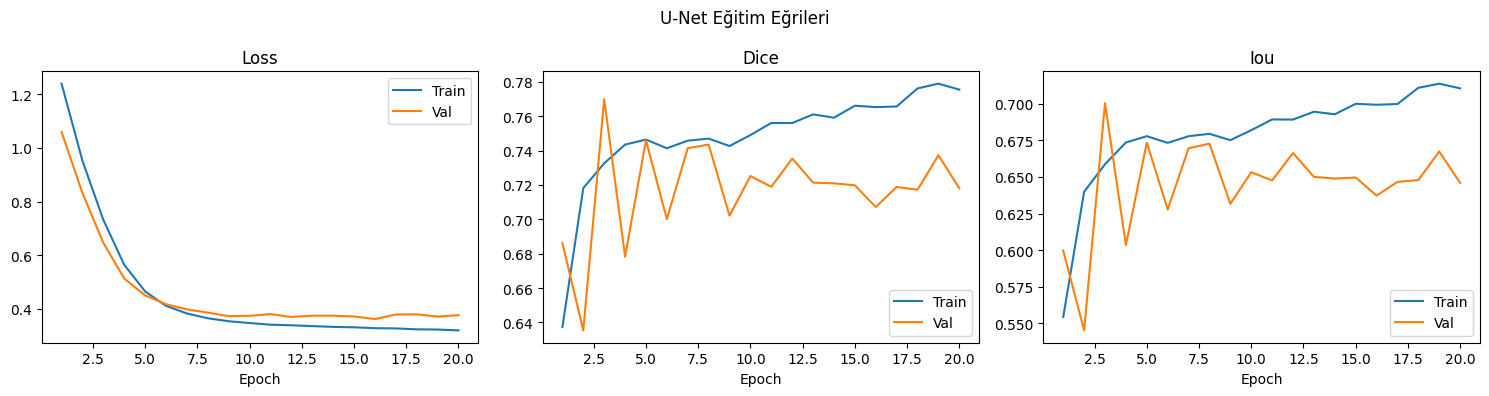

In [13]:
# ── Eğitim eğrileri ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["loss", "dice", "iou"]):
    ax.plot(history_df["epoch"], history_df[f"train_{metric}"], label="Train")
    ax.plot(history_df["epoch"], history_df[f"val_{metric}"],   label="Val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
plt.suptitle("U-Net Eğitim Eğrileri")
plt.tight_layout()
plt.show()


In [14]:
# ── U-Net final test değerlendirmesi ─────────────────────────────────────
unet.load_state_dict(torch.load(BEST_UNET_PATH, map_location=DEVICE))
unet.eval()

t_eval = time.perf_counter()
_, test_dice_all,   test_iou_all   = run_epoch(unet, test_loader,            criterion, None, None, DEVICE, train=False)
_, test_dice_tumor, test_iou_tumor = run_epoch(unet, test_loader_tumor_only, criterion, None, None, DEVICE, train=False)
unet_eval_sec = time.perf_counter() - t_eval

unet_results = {
    "Model":   "U-Net",
    "Setting": "Trained 2D baseline, tumor-positive test",
    "Dice":    test_dice_tumor,
    "IoU":     test_iou_tumor,
    "N":       len(test_files_tumor_only),
}

timing_records.append({
    "Model":                    "U-Net",
    "Training Type":            "Supervised (BraTS2020)",
    "Training Time":            format_seconds(unet_training_sec),
    "Evaluation Time":          format_seconds(unet_eval_sec),
    "Samples Evaluated":        len(test_files_tumor_only),
    "Notes":                    f"{EPOCHS} epoch, {IMAGE_SIZE_UNET}×{IMAGE_SIZE_UNET}, batch={BATCH_SIZE}"
})

print(f"U-Net  (tüm test)        — Dice: {test_dice_all:.4f} | IoU: {test_iou_all:.4f}")
print(f"U-Net  (tumor-only test) — Dice: {test_dice_tumor:.4f} | IoU: {test_iou_tumor:.4f}")


U-Net  (tüm test)        — Dice: 0.7624 | IoU: 0.6903
U-Net  (tumor-only test) — Dice: 0.7583 | IoU: 0.6720


## 5. SAM: Genel Amaçlı Foundation Model (Baseline)

SAM (Segment Anything Model), natural image'lar üzerinde eğitilmiş genel amaçlı
bir foundation modelidir. Burada **zero-shot** olarak değerlendirilir.

**Prompt stratejisi:** Ground-truth maskeden türetilen bounding box (oracle prompt).  
Bu kontrollü karşılaştırma için standart bir yaklaşımdır ve raporda belirtilmelidir.

**Beklenti:** SAM'ın medikal görüntülerde, özellikle düşük kontrast ve belirsiz
sınırlar nedeniyle, U-Net'e kıyasla daha düşük performans göstermesi beklenir.


In [15]:
# ── SAM ViT-B yükleme ────────────────────────────────────────────────────
from segment_anything import sam_model_registry, SamPredictor

SAM_DIR        = "/content/sam_checkpoints"
SAM_CHECKPOINT = os.path.join(SAM_DIR, "sam_vit_b_01ec64.pth")
os.makedirs(SAM_DIR, exist_ok=True)

if not os.path.exists(SAM_CHECKPOINT):
    !wget -q -O {SAM_CHECKPOINT} https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

sam           = sam_model_registry["vit_b"](checkpoint=SAM_CHECKPOINT)
sam.to(device=DEVICE).eval()
sam_predictor = SamPredictor(sam)
print("SAM yüklendi:", SAM_CHECKPOINT)


SAM yüklendi: /content/sam_checkpoints/sam_vit_b_01ec64.pth


In [16]:
# ── Genel SAM/MedSAM değerlendirme fonksiyonu ────────────────────────────
def predictor_predict_mask(path, predictor, image_size=256, use_channels=(0,1,3),
                            padding=5, use_box=True, num_pos=0, num_neg=0,
                            mask_choice="score", postprocess=False, seed=42,
                            medsam_mode=False):
    """
    Tek bir slice için SAM veya MedSAM tahmini yapar.
    medsam_mode=True ise MedSAM preprocessing kullanır.
    """
    if medsam_mode:
        image_uint8, gt_mask = prepare_h5_for_medsam(path, image_size, use_channels)
    else:
        image_uint8, gt_mask = prepare_h5_rgb(path, image_size, use_channels)

    bbox = get_bbox_from_mask(gt_mask, padding=padding)
    if bbox is None:
        return image_uint8, gt_mask, np.zeros_like(gt_mask, dtype=np.uint8), None

    point_coords, point_labels = sample_points(gt_mask, bbox=bbox,
                                               num_pos=num_pos, num_neg=num_neg, seed=seed)
    predictor.set_image(image_uint8)
    masks, scores, _ = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        box=bbox if use_box else None,
        multimask_output=True,
    )
    best_idx = {"score": int(np.argmax(scores)),
                "mask0": 0,
                "mask1": min(1, masks.shape[0]-1),
                "mask2": min(2, masks.shape[0]-1)}.get(mask_choice, int(np.argmax(scores)))
    pred = masks[best_idx].astype(np.uint8)
    if postprocess:
        pred = keep_largest_component(pred)
    return image_uint8, gt_mask, pred, scores

def evaluate_predictor_on_files(files, predictor, config, max_samples=None,
                                 desc="Evaluating", medsam_mode=False):
    """Dosya listesi üzerinde predictor değerlendirme döngüsü."""
    eval_files = files[:max_samples] if max_samples else files
    rows  = []
    t0    = time.perf_counter()
    for i, path in enumerate(tqdm(eval_files, desc=desc)):
        _, gt, pred, _ = predictor_predict_mask(path, predictor, seed=SEED+i,
                                                 medsam_mode=medsam_mode, **config)
        rows.append({"path": path, "dice": dice_np(pred, gt), "iou": iou_np(pred, gt)})
    elapsed = time.perf_counter() - t0
    df = pd.DataFrame(rows)
    return {
        "dice_mean": float(df["dice"].mean()), "dice_std": float(df["dice"].std(ddof=0)),
        "iou_mean":  float(df["iou"].mean()),  "iou_std":  float(df["iou"].std(ddof=0)),
        "n": len(df), "elapsed_sec": float(elapsed),
        "sec_per_sample": float(elapsed / max(1, len(df))), "df": df
    }

print("SAM/MedSAM değerlendirme fonksiyonları tanımlandı.")


SAM/MedSAM değerlendirme fonksiyonları tanımlandı.


In [17]:
# ── SAM baseline değerlendirme ────────────────────────────────────────────
# Not: 256x256 input, channels=(0,1,3), padding=5, box-only prompt
sam_config = dict(
    image_size=IMAGE_SIZE_SAM_BASELINE,
    use_channels=(0, 1, 3),
    padding=5,
    use_box=True,
    num_pos=0, num_neg=0,
    mask_choice="score",
    postprocess=False,
)

t_sam = time.perf_counter()
sam_raw = evaluate_predictor_on_files(
    test_files_tumor_only, sam_predictor, sam_config,
    max_samples=None, desc="SAM baseline — test set"
)
sam_eval_sec = time.perf_counter() - t_sam

sam_raw["df"].to_csv(os.path.join(OUTPUT_DIR, "sam_per_sample_results.csv"), index=False)

sam_results = {
    "Model":   "SAM",
    "Setting": "Zero-shot + GT-derived box prompt, tumor-positive test",
    "Dice":    sam_raw["dice_mean"],
    "IoU":     sam_raw["iou_mean"],
    "N":       sam_raw["n"],
}

timing_records.append({
    "Model":             "SAM",
    "Training Type":     "Zero-shot",
    "Training Time":     "0 sec",
    "Evaluation Time":   format_seconds(sam_eval_sec),
    "Samples Evaluated": sam_raw["n"],
    "Notes":             f"SAM ViT-B, {sam_config['image_size']}×{sam_config['image_size']}, GT-box"
})

print(f"SAM — Dice: {sam_raw['dice_mean']:.4f} ± {sam_raw['dice_std']:.4f}")
print(f"SAM — IoU : {sam_raw['iou_mean']:.4f} ± {sam_raw['iou_std']:.4f}")
print(f"Süre      : {format_seconds(sam_eval_sec)}")


SAM baseline — test set: 100%|██████████| 3881/3881 [08:09<00:00,  7.92it/s]

SAM — Dice: 0.6304 ± 0.2319
SAM — IoU : 0.4992 ± 0.2332
Süre      : 8.17 min


## 6. MedSAM: Medikal Domain Foundation Model

MedSAM, SAM'ın 1.5 milyondan fazla medikal görüntü-maske çifti üzerinde
fine-tune edilmiş versiyonudur. Medikal görüntülerdeki düşük kontrast ve
belirsiz sınır problemleri için domain adaptasyonu sağlar.

### Parametre Optimizasyon Stratejisi
**Tüm optimizasyon yalnızca validation seti üzerinde yapılır.**  
Test seti sadece final rapor için bir kez kullanılır.

Optimizasyon sırası:
1. MRI kanal kombinasyonu
2. Bounding box padding değeri (ince ayar dahil)
3. Mask seçim kuralı ve postprocessing
4. Prompt stratejisi (nokta prompt desteği)


In [18]:
# ── MedSAM yükleme ───────────────────────────────────────────────────────
%cd /content
if not os.path.exists("/content/MedSAM"):
    !git clone -q https://github.com/bowang-lab/MedSAM.git /content/MedSAM

%cd /content/MedSAM
!pip install -q -e .
%cd /content

MEDSAM_CKPT_DIR  = "/content/MedSAM/work_dir/MedSAM"
MEDSAM_CKPT_PATH = os.path.join(MEDSAM_CKPT_DIR, "medsam_vit_b.pth")
os.makedirs(MEDSAM_CKPT_DIR, exist_ok=True)

if not os.path.exists(MEDSAM_CKPT_PATH):
    !wget -q -O {MEDSAM_CKPT_PATH} "https://zenodo.org/records/10689643/files/medsam_vit_b.pth?download=1"

medsam           = sam_model_registry["vit_b"](checkpoint=MEDSAM_CKPT_PATH)
medsam.to(device=DEVICE).eval()
medsam_predictor = SamPredictor(medsam)
print("MedSAM yüklendi:", MEDSAM_CKPT_PATH)


/content
/content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.0 MB/s eta 0:00:00
/content
MedSAM yüklendi: /content/MedSAM/work_dir/MedSAM/medsam_vit_b.pth


In [19]:
# ── Adım A: MRI kanal kombinasyonu optimizasyonu ──────────────────────────
# MedSAM RGB benzeri 3-kanallı input bekler. BraTS2020'de 4 MRI modalitesi
# (FLAIR, T1, T1ce, T2) mevcut; hangilerinin kullanılacağı performansı etkiler.
# Ayrıca tek modaliteyi 3 kanala kopyalamak da test edilir.

channel_sets = {
    "013": (0,1,3), "012": (0,1,2), "023": (0,2,3), "123": (1,2,3),
    "000": (0,0,0), "111": (1,1,1), "222": (2,2,2), "333": (3,3,3),
}

channel_rows = []
base_cfg = dict(image_size=IMAGE_SIZE_MEDSAM, padding=15, use_box=True,
                num_pos=0, num_neg=0, mask_choice="score", postprocess=False)

for name, chs in channel_sets.items():
    cfg = dict(base_cfg, use_channels=chs)
    res = evaluate_predictor_on_files(val_files_tumor_only, medsam_predictor, cfg,
                                       max_samples=VAL_TUNE_SAMPLES, medsam_mode=True,
                                       desc=f"Kanal {name}")
    channel_rows.append({"channels_name": name, "channels": chs,
                          "dice": res["dice_mean"], "iou": res["iou_mean"]})
    print(f"  {name} {chs}: Dice={res['dice_mean']:.4f}, IoU={res['iou_mean']:.4f}")

channel_df = pd.DataFrame(channel_rows).sort_values("dice", ascending=False).reset_index(drop=True)
channel_df.to_csv(os.path.join(OUTPUT_DIR, "medsam_channel_tuning.csv"), index=False)
best_channels = tuple(channel_df.iloc[0]["channels"])
print(f"\nEn iyi kanallar: {best_channels}")
channel_df


Kanal 013: 100%|██████████| 1000/1000 [02:35<00:00,  6.41it/s]


  013 (0, 1, 3): Dice=0.7187, IoU=0.5928


Kanal 012: 100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]


  012 (0, 1, 2): Dice=0.7473, IoU=0.6293


Kanal 023: 100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]


...

Kanal 222: 100%|██████████| 1000/1000 [02:37<00:00,  6.36it/s]


  222 (2, 2, 2): Dice=0.6274, IoU=0.4846


Kanal 333: 100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]

  333 (3, 3, 3): Dice=0.6375, IoU=0.5091

En iyi kanallar: (0, 1, 2)


,channels_name,channels,dice,iou
0,012,"(0, 1, 2)",0.747300,0.629258
1,000,"(0, 0, 0)",0.732312,0.609960
2,023,"(0, 2, 3)",0.724682,0.600667
3,013,"(0, 1, 3)",0.718686,0.592773
4,123,"(1, 2, 3)",0.659291,0.520077
5,111,"(1, 1, 1)",0.655155,0.515688
6,333,"(3, 3, 3)",0.637478,0.509128
7,222,"(2, 2, 2)",0.627423,0.484599


In [20]:
# ── Adım B: Bounding box padding kaba arama ──────────────────────────────
# Padding tümörün ne kadar geniş bir box içinde sunulacağını belirler.
# Çok küçük: tümörü kaçırabilir; çok büyük: gürültü artar.

padding_coarse = [0, 3, 5, 8, 10, 12, 15, 18, 20, 25, 30]
padding_rows   = []

for pad in padding_coarse:
    cfg = dict(image_size=IMAGE_SIZE_MEDSAM, use_channels=best_channels,
               padding=pad, use_box=True, num_pos=0, num_neg=0,
               mask_choice="score", postprocess=False)
    res = evaluate_predictor_on_files(val_files_tumor_only, medsam_predictor, cfg,
                                       max_samples=VAL_TUNE_SAMPLES, medsam_mode=True,
                                       desc=f"Padding {pad}")
    padding_rows.append({"padding": pad, "dice": res["dice_mean"], "iou": res["iou_mean"]})
    print(f"  Padding {pad:2d}: Dice={res['dice_mean']:.4f}, IoU={res['iou_mean']:.4f}")

padding_df   = pd.DataFrame(padding_rows).sort_values("dice", ascending=False).reset_index(drop=True)
best_padding = int(padding_df.iloc[0]["padding"])
padding_df.to_csv(os.path.join(OUTPUT_DIR, "medsam_padding_tuning.csv"), index=False)
print(f"\nEn iyi padding (kaba): {best_padding}")


Padding 0: 100%|██████████| 1000/1000 [02:37<00:00,  6.34it/s]


  Padding  0: Dice=0.7097, IoU=0.5894


Padding 3: 100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]


  Padding  3: Dice=0.7246, IoU=0.6055


Padding 5: 100%|██████████| 1000/1000 [02:37<00:00,  6.36it/s]


...

  Padding 20: Dice=0.7403, IoU=0.6214


Padding 25: 100%|██████████| 1000/1000 [02:37<00:00,  6.37it/s]


  Padding 25: Dice=0.7251, IoU=0.6044


Padding 30: 100%|██████████| 1000/1000 [02:37<00:00,  6.34it/s]

  Padding 30: Dice=0.7028, IoU=0.5792

En iyi padding (kaba): 15


In [21]:
# ── Adım C: Padding ince ayarı ───────────────────────────────────────────
fine_pads = sorted(set([max(0, best_padding + d) for d in [-5,-3,-2,-1,0,1,2,3,5]]))
fine_rows = []

for pad in fine_pads:
    cfg = dict(image_size=IMAGE_SIZE_MEDSAM, use_channels=best_channels,
               padding=pad, use_box=True, num_pos=0, num_neg=0,
               mask_choice="score", postprocess=False)
    res = evaluate_predictor_on_files(val_files_tumor_only, medsam_predictor, cfg,
                                       max_samples=VAL_TUNE_SAMPLES, medsam_mode=True,
                                       desc=f"İnce padding {pad}")
    fine_rows.append({"padding": pad, "dice": res["dice_mean"], "iou": res["iou_mean"]})
    print(f"  İnce padding {pad:2d}: Dice={res['dice_mean']:.4f}, IoU={res['iou_mean']:.4f}")

fine_padding_df = pd.DataFrame(fine_rows).sort_values("dice", ascending=False).reset_index(drop=True)
fine_padding_df.to_csv(os.path.join(OUTPUT_DIR, "medsam_fine_padding_tuning.csv"), index=False)
best_padding = int(fine_padding_df.iloc[0]["padding"])
print(f"\nEn iyi padding (ince ayar): {best_padding}")


İnce padding 10: 100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]


  İnce padding 10: Dice=0.7447, IoU=0.6266


İnce padding 12: 100%|██████████| 1000/1000 [02:37<00:00,  6.36it/s]


  İnce padding 12: Dice=0.7470, IoU=0.6289


İnce padding 13: 100%|██████████| 1000/1000 [02:37<00:00,  6.36it/s]


...

  İnce padding 17: Dice=0.7451, IoU=0.6269


İnce padding 18: 100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]


  İnce padding 18: Dice=0.7439, IoU=0.6255


İnce padding 20: 100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]

  İnce padding 20: Dice=0.7403, IoU=0.6214

En iyi padding (ince ayar): 15


In [22]:
# ── Adım D: Mask seçimi ve postprocessing ────────────────────────────────
# SAM/MedSAM her çağrıda 3 farklı maske üretir.
# Hangisinin seçileceği (score, mask0, mask1, mask2) ve
# LCC postprocessing uygulanıp uygulanmayacağı test edilir.

mask_rows = []
for mask_choice in ["score", "mask0", "mask1", "mask2"]:
    for postprocess in [False, True]:
        cfg = dict(image_size=IMAGE_SIZE_MEDSAM, use_channels=best_channels,
                   padding=best_padding, use_box=True, num_pos=0, num_neg=0,
                   mask_choice=mask_choice, postprocess=postprocess)
        res = evaluate_predictor_on_files(val_files_tumor_only, medsam_predictor, cfg,
                                           max_samples=VAL_TUNE_SAMPLES, medsam_mode=True,
                                           desc=f"{mask_choice} pp={postprocess}")
        mask_rows.append({"mask_choice": mask_choice, "postprocess": postprocess,
                           "dice": res["dice_mean"], "iou": res["iou_mean"]})
        print(f"  {mask_choice}, pp={postprocess}: Dice={res['dice_mean']:.4f}, IoU={res['iou_mean']:.4f}")

mask_df            = pd.DataFrame(mask_rows).sort_values("dice", ascending=False).reset_index(drop=True)
best_mask_choice   = str(mask_df.iloc[0]["mask_choice"])
best_postprocess   = bool(mask_df.iloc[0]["postprocess"])
mask_df.to_csv(os.path.join(OUTPUT_DIR, "medsam_mask_choice_tuning.csv"), index=False)
print(f"\nEn iyi mask seçimi : {best_mask_choice}")
print(f"En iyi postprocess  : {best_postprocess}")


score pp=False: 100%|██████████| 1000/1000 [02:37<00:00,  6.36it/s]


  score, pp=False: Dice=0.7473, IoU=0.6293


score pp=True: 100%|██████████| 1000/1000 [02:52<00:00,  5.81it/s]


  score, pp=True: Dice=0.7482, IoU=0.6308


mask0 pp=False: 100%|██████████| 1000/1000 [02:37<00:00,  6.35it/s]


...

  mask1, pp=True: Dice=0.7500, IoU=0.6327


mask2 pp=False: 100%|██████████| 1000/1000 [02:36<00:00,  6.38it/s]


  mask2, pp=False: Dice=0.6569, IoU=0.5259


mask2 pp=True: 100%|██████████| 1000/1000 [02:52<00:00,  5.80it/s]

  mask2, pp=True: Dice=0.6473, IoU=0.5174

En iyi mask seçimi : mask1
En iyi postprocess  : True


In [23]:
# ── Adım E: Prompt stratejisi doğrulama ──────────────────────────────────
# Önceki deneylerde box-only prompt en iyi sonucu verdi.
# Bu adımda alternatifler ile karşılaştırılarak doğrulanır.

prompt_strategies = [
    {"name": "box_only",       "use_box": True,  "num_pos": 0,  "num_neg": 0},
    {"name": "box_3pos",       "use_box": True,  "num_pos": 3,  "num_neg": 0},
    {"name": "box_3pos_3neg",  "use_box": True,  "num_pos": 3,  "num_neg": 3},
]

prompt_rows = []
for s in prompt_strategies:
    cfg = dict(image_size=IMAGE_SIZE_MEDSAM, use_channels=best_channels,
               padding=best_padding, use_box=s["use_box"],
               num_pos=s["num_pos"], num_neg=s["num_neg"],
               mask_choice=best_mask_choice, postprocess=best_postprocess)
    res = evaluate_predictor_on_files(val_files_tumor_only, medsam_predictor, cfg,
                                       max_samples=VAL_TUNE_SAMPLES, medsam_mode=True,
                                       desc=f"Prompt {s['name']}")
    prompt_rows.append({**s, "dice": res["dice_mean"], "iou": res["iou_mean"]})
    print(f"  {s['name']}: Dice={res['dice_mean']:.4f}, IoU={res['iou_mean']:.4f}")

prompt_df = pd.DataFrame(prompt_rows).sort_values("dice", ascending=False).reset_index(drop=True)
best_row  = prompt_df.iloc[0]

# Final MedSAM konfigürasyonu
best_medsam_config = dict(
    image_size    = IMAGE_SIZE_MEDSAM,
    use_channels  = best_channels,
    padding       = best_padding,
    use_box       = bool(best_row["use_box"]),
    num_pos       = int(best_row["num_pos"]),
    num_neg       = int(best_row["num_neg"]),
    mask_choice   = best_mask_choice,
    postprocess   = best_postprocess,
)

prompt_df.to_csv(os.path.join(OUTPUT_DIR, "medsam_prompt_strategy_tuning.csv"), index=False)
print("\nFinal MedSAM konfigürasyonu:")
for k, v in best_medsam_config.items():
    print(f"  {k}: {v}")


Prompt box_only: 100%|██████████| 1000/1000 [02:52<00:00,  5.80it/s]


  box_only: Dice=0.7500, IoU=0.6327


Prompt box_3pos: 100%|██████████| 1000/1000 [02:41<00:00,  6.18it/s]


  box_3pos: Dice=0.3200, IoU=0.2279


Prompt box_3pos_3neg: 100%|██████████| 1000/1000 [02:45<00:00,  6.04it/s]

  box_3pos_3neg: Dice=0.1316, IoU=0.0889

Final MedSAM konfigürasyonu:
  image_size: 1024
  use_channels: (0, 1, 2)
  padding: 15
  use_box: True
  num_pos: 0
  num_neg: 0
  mask_choice: mask1
  postprocess: True


In [24]:
# ── MedSAM final test değerlendirmesi ────────────────────────────────────
# Optimizasyon tamamen tamamlandı; test seti burada ilk kez kullanılır.

t_medsam = time.perf_counter()
medsam_raw = evaluate_predictor_on_files(
    test_files_tumor_only, medsam_predictor, best_medsam_config,
    max_samples=None, desc="MedSAM Final Test", medsam_mode=True
)
medsam_eval_sec = time.perf_counter() - t_medsam

medsam_raw["df"].to_csv(os.path.join(OUTPUT_DIR, "medsam_optimized_per_sample_results.csv"), index=False)

medsam_results = {
    "Model":   "MedSAM-Optimized",
    "Setting": (
        f"GT-box prompt, {best_medsam_config['image_size']}×{best_medsam_config['image_size']}, "
        f"channels={best_medsam_config['use_channels']}, pad={best_medsam_config['padding']}, "
        f"mask={best_medsam_config['mask_choice']}, pp={best_medsam_config['postprocess']}, "
        f"prompt=box+{best_medsam_config['num_pos']}pos"
    ),
    "Dice": medsam_raw["dice_mean"],
    "IoU":  medsam_raw["iou_mean"],
    "N":    medsam_raw["n"],
}

timing_records.append({
    "Model":             "MedSAM-Optimized",
    "Training Type":     "Zero-shot (val-only prompt optimization)",
    "Training Time":     "0 sec",
    "Evaluation Time":   format_seconds(medsam_eval_sec),
    "Samples Evaluated": medsam_raw["n"],
    "Notes":             medsam_results["Setting"]
})

print(f"MedSAM — Dice: {medsam_raw['dice_mean']:.4f} ± {medsam_raw['dice_std']:.4f}")
print(f"MedSAM — IoU : {medsam_raw['iou_mean']:.4f} ± {medsam_raw['iou_std']:.4f}")
print(f"Süre          : {format_seconds(medsam_eval_sec)}")


MedSAM Final Test: 100%|██████████| 3881/3881 [10:08<00:00,  6.38it/s]

MedSAM — Dice: 0.7338 ± 0.2068
MedSAM — IoU : 0.6143 ± 0.2166
Süre          : 10.14 min


## 7. Final Karşılaştırma Tablosu ve Görselleştirme

Tüm modeller tumor-positive test slice'ları üzerinde değerlendirildi.

**Önemli bağlam:**
- U-Net BraTS2020 üzerinde **supervised** eğitildi → bu veri setinde avantajlı.
- SAM ve MedSAM **zero-shot** değerlendirildi → eğitim verisi kullanmadı.
- MedSAM'ın U-Net'i geçememesi beklenen bir sonuç: görev-spesifik eğitimin
  zero-shot adaptasyondan üstün olduğunu gösterir.
- MedSAM SAM'ı belirgin biçimde geçiyorsa domain adaptasyonunun etkisi kanıtlanmış olur.


In [25]:
# ── Final karşılaştırma tablosu ───────────────────────────────────────────
comparison_df = pd.DataFrame([unet_results, sam_results, medsam_results])
comparison_df["Dice"] = comparison_df["Dice"].astype(float)
comparison_df["IoU"]  = comparison_df["IoU"].astype(float)
comparison_df = comparison_df.sort_values("Dice", ascending=False).reset_index(drop=True)

comparison_df.to_csv(os.path.join(OUTPUT_DIR, "final_unet_sam_medsam_comparison.csv"), index=False)
print(comparison_df[["Model", "Dice", "IoU", "N"]].to_string(index=False))


           Model     Dice      IoU    N
           U-Net 0.758322 0.671961 3881
MedSAM-Optimized 0.733777 0.614329 3881
             SAM 0.630408 0.499160 3881


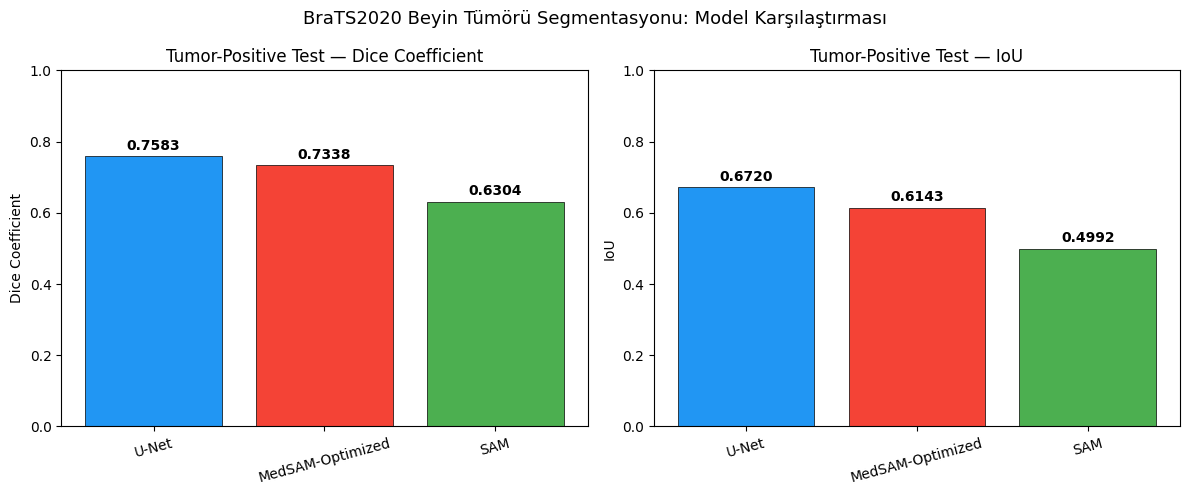

In [26]:
# ── Görsel karşılaştırma ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["#2196F3", "#F44336", "#4CAF50"]
models = comparison_df["Model"].tolist()
dices  = comparison_df["Dice"].tolist()
ious   = comparison_df["IoU"].tolist()

for ax, vals, title in zip(axes, [dices, ious], ["Dice Coefficient", "IoU"]):
    bars = ax.bar(models, vals, color=colors[:len(models)], edgecolor="black", linewidth=0.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel(title)
    ax.set_title(f"Tumor-Positive Test — {title}")
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("BraTS2020 Beyin Tümörü Segmentasyonu: Model Karşılaştırması", fontsize=13)
plt.tight_layout()
plt.show()


In [27]:
# ── Süre karşılaştırma tablosu ───────────────────────────────────────────
timing_df = pd.DataFrame(timing_records)
timing_df.to_csv(os.path.join(OUTPUT_DIR, "timing_comparison.csv"), index=False)
print(timing_df[["Model", "Training Type", "Training Time", "Evaluation Time",
                  "Samples Evaluated"]].to_string(index=False))


           Model                            Training Type Training Time Evaluation Time  Samples Evaluated
           U-Net                   Supervised (BraTS2020)     53.23 min        1.22 min               3881
             SAM                                Zero-shot         0 sec        8.17 min               3881
MedSAM-Optimized Zero-shot (val-only prompt optimization)         0 sec       10.14 min               3881


## 8. Nitel Analiz: Tek Slice Karşılaştırması

Bu bölümde test setinden seçilen örnekler üzerinde üç modelin tahminleri
görsel olarak karşılaştırılır. Özellikle:
- Sınır hassasiyeti
- Tümör lokalizasyonu
- Düşük kontrast ve belirsiz sınır durumları


In [28]:
# ── Tek slice tahmin fonksiyonları ────────────────────────────────────────
@torch.no_grad()
def predict_unet_single(path):
    image_uint8, gt = prepare_h5_rgb(path, IMAGE_SIZE_UNET, UNET_CHANNELS)
    x = torch.from_numpy(image_uint8.astype(np.float32) / 255.0).permute(2,0,1).unsqueeze(0).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
        logits = unet(x)
    pred = (torch.sigmoid(logits)[0,0].cpu().numpy() > 0.5).astype(np.uint8)
    return image_uint8, gt, pred

def predict_sam_single(path):
    img, gt, pred, _ = predictor_predict_mask(path, sam_predictor, **sam_config)
    return img, gt, pred

def predict_medsam_single(path):
    img_1024, gt_1024, pred_1024, _ = predictor_predict_mask(
        path, medsam_predictor, medsam_mode=True, **best_medsam_config
    )
    # 256'ya downsample (görselleştirme için)
    pred_256 = cv2.resize(pred_1024.astype(np.uint8), (256, 256), interpolation=cv2.INTER_NEAREST)
    gt_256   = cv2.resize(gt_1024.astype(np.uint8),   (256, 256), interpolation=cv2.INTER_NEAREST)
    img_256  = cv2.resize(img_1024, (256, 256), interpolation=cv2.INTER_LINEAR)
    return img_256, gt_256, pred_256

def compare_models_on_slice(path, show=True):
    """Tek slice üzerinde U-Net, SAM ve MedSAM karşılaştırması."""
    unet_img,   unet_gt,   unet_pred   = predict_unet_single(path)
    sam_img,    sam_gt,    sam_pred    = predict_sam_single(path)
    medsam_img, medsam_gt, medsam_pred = predict_medsam_single(path)

    scores = pd.DataFrame([
        {"Model": "U-Net",            "Dice": dice_np(unet_pred,   unet_gt),
                                       "IoU":  iou_np(unet_pred,   unet_gt)},
        {"Model": "SAM",              "Dice": dice_np(sam_pred,    sam_gt),
                                       "IoU":  iou_np(sam_pred,    sam_gt)},
        {"Model": "MedSAM-Optimized", "Dice": dice_np(medsam_pred, medsam_gt),
                                       "IoU":  iou_np(medsam_pred, medsam_gt)},
    ])

    if show:
        fig, axes = plt.subplots(2, 4, figsize=(20, 9))

        axes[0,0].imshow(medsam_img)
        axes[0,0].set_title("Input MRI")
        axes[0,1].imshow(medsam_gt, cmap="gray")
        axes[0,1].set_title("Ground Truth")
        axes[0,2].imshow(unet_pred, cmap="gray")
        axes[0,2].set_title(f"U-Net\nDice={scores[scores.Model=='U-Net'].Dice.iloc[0]:.3f}")
        axes[0,3].imshow(sam_pred, cmap="gray")
        axes[0,3].set_title(f"SAM\nDice={scores[scores.Model=='SAM'].Dice.iloc[0]:.3f}")
        axes[1,0].imshow(medsam_pred, cmap="gray")
        axes[1,0].set_title(f"MedSAM-Opt\nDice={scores[scores.Model=='MedSAM-Optimized'].Dice.iloc[0]:.3f}")
        axes[1,1].imshow(medsam_img); axes[1,1].imshow(medsam_gt,   cmap="Greens", alpha=0.4)
        axes[1,1].set_title("GT Overlay")
        axes[1,2].imshow(medsam_img); axes[1,2].imshow(medsam_pred, cmap="Reds",   alpha=0.4)
        axes[1,2].set_title("MedSAM Overlay")
        axes[1,3].axis("off")
        axes[1,3].text(0.05, 0.9, scores.to_string(index=False, float_format=lambda x: f"{x:.4f}"),
                       family="monospace", fontsize=10, va="top", transform=axes[1,3].transAxes)
        axes[1,3].set_title("Per-sample Scores")

        for ax in axes.flat:
            ax.axis("off")

        plt.suptitle(os.path.basename(path), fontsize=11)
        plt.tight_layout()
        plt.show()

    return scores

print("Tek slice karşılaştırma fonksiyonu hazır.")


Tek slice karşılaştırma fonksiyonu hazır.


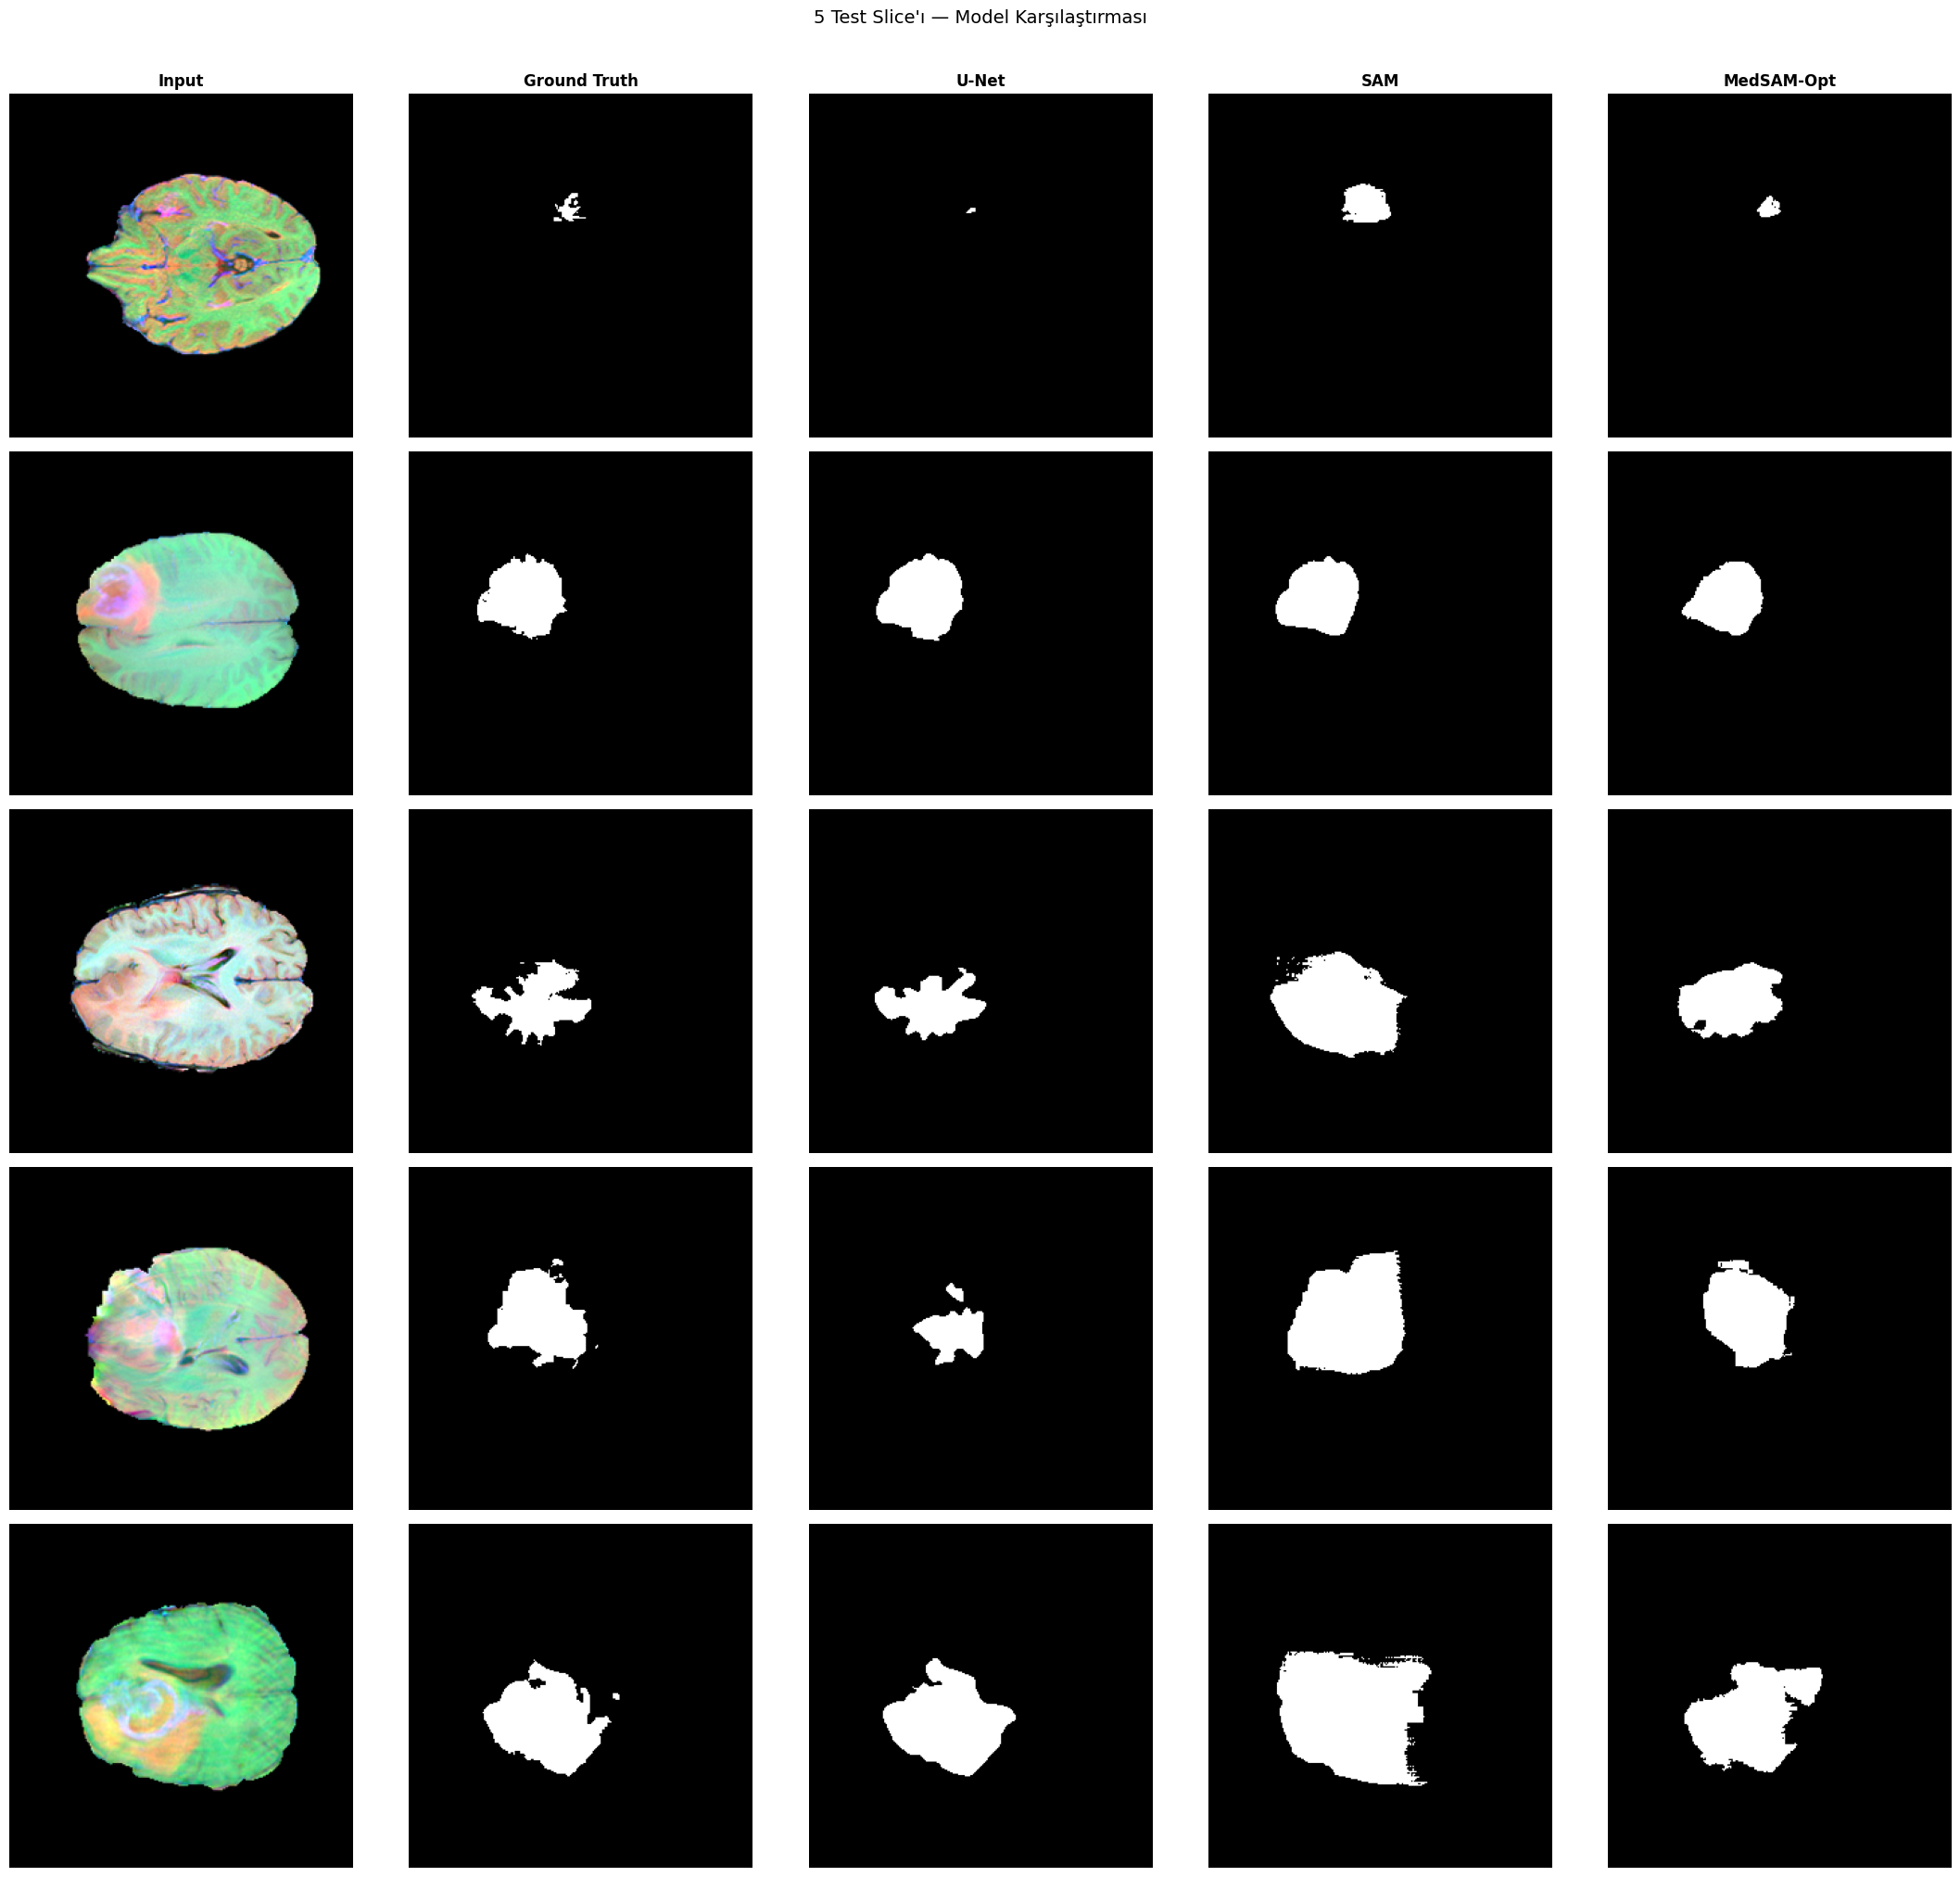

In [30]:
# ── 5 farklı slice üzerinde grid görselleştirme ───────────────────────────
# Tümör boyutu ve konumuna göre farklı örnekler seçilir.

n_samples  = 5
sample_paths = random.sample(test_files_tumor_only, n_samples)

fig, axes = plt.subplots(n_samples, 5, figsize=(22, 4 * n_samples))
col_titles = ["Input", "Ground Truth", "U-Net", "SAM", "MedSAM-Opt"]

for row, path in enumerate(sample_paths):
    unet_img,   unet_gt,   unet_pred   = predict_unet_single(path)
    sam_img,    sam_gt,    sam_pred    = predict_sam_single(path)
    medsam_img, medsam_gt, medsam_pred = predict_medsam_single(path)

    preds  = [medsam_img, medsam_gt, unet_pred, sam_pred, medsam_pred]
    cmaps  = [None, "gray", "gray", "gray", "gray"]

    for col, (img, cmap) in enumerate(zip(preds, cmaps)):
        axes[row, col].imshow(img, cmap=cmap)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=12, fontweight="bold")

plt.suptitle("5 Test Slice'ı — Model Karşılaştırması", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 9. İnteraktif Demo

İki kullanım seçeneği:
1. **Dropdown menüsü:** Test setinden slice seçerek karşılaştır.
2. **H5 yükleme:** Kendi `.h5` dosyanı yükleyerek karşılaştır.


In [31]:
# ── Dropdown ile test slice seçimi ────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

DEMO_FILES = test_files_tumor_only[:300]
options    = [(os.path.basename(p), p) for p in DEMO_FILES]

dropdown       = widgets.Dropdown(options=options, description="Slice:",
                                   layout=widgets.Layout(width="600px"))
random_button  = widgets.Button(description="Rastgele seç", button_style="info")
run_button     = widgets.Button(description="Karşılaştır",  button_style="success")
out            = widgets.Output()

def on_random(_):
    dropdown.value = random.choice(DEMO_FILES)

def on_run(_):
    with out:
        clear_output(wait=True)
        print("Seçili:", dropdown.label)
        scores = compare_models_on_slice(dropdown.value, show=True)
        display(scores)

random_button.on_click(on_random)
run_button.on_click(on_run)
display(widgets.HBox([dropdown, random_button, run_button]))
display(out)


Output()

In [32]:
# ── H5 dosyası yükleme (upload demo) ─────────────────────────────────────
upload        = widgets.FileUpload(accept=".h5", multiple=False, description="H5 yükle")
upload_button = widgets.Button(description="Karşılaştır", button_style="warning")
upload_out    = widgets.Output()

def on_upload_run(_):
    with upload_out:
        clear_output(wait=True)
        if len(upload.value) == 0:
            print("Lütfen önce bir .h5 dosyası yükle.")
            return
        item      = list(upload.value.values())[0]
        save_path = os.path.join("/content", item["metadata"]["name"])
        with open(save_path, "wb") as f:
            f.write(item["content"])
        print("Yüklenen dosya:", save_path)
        scores = compare_models_on_slice(save_path, show=True)
        display(scores)

upload_button.on_click(on_upload_run)
display(widgets.HBox([upload, upload_button]))
display(upload_out)


Output()